In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/DS102

Mounted at /content/drive
/content/drive/MyDrive/DS102


Đọc JSON dạng lines OK: ./preprocessed-dataset/train_processed.json
Đọc JSON dạng lines OK: ./preprocessed-dataset/dev_processed.json
Đọc JSON dạng lines OK: ./preprocessed-dataset/test_processed.json
Train shape: (1710, 2)
Val shape: (244, 2)
Test shape: (490, 2)
Classes: ['negative', 'neutral', 'positive']
Train label distribution:
 sentiment
neutral     674
negative    529
positive    507
Name: count, dtype: int64
Đang GridSearchCV (F1-macro) trên TRAIN...
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best CV F1-macro: 0.49274905485472137
Best params:
dt__criterion: gini
dt__max_depth: 50
dt__min_samples_leaf: 7
dt__min_samples_split: 3
tfidf__max_df: 0.1
tfidf__min_df: 2
tfidf__ngram_range: (1, 4)
tfidf__norm: l2
tfidf__sublinear_tf: False

DEV Accuracy: 0.5245901639344263
DEV F1-macro: 0.5239026177942301

Classification report (DEV):
              precision    recall  f1-score   support

    negative       0.58      0.55      0.56        76
     neutral       0.53   

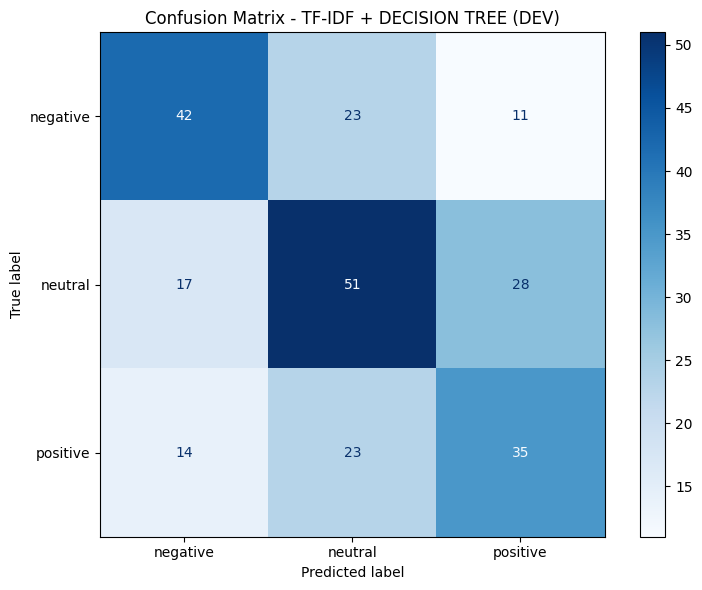


TEST Accuracy: 0.5306122448979592
TEST F1-macro: 0.527270260256029

Classification report (TEST):
              precision    recall  f1-score   support

    negative       0.53      0.46      0.50       151
     neutral       0.54      0.57      0.56       194
    positive       0.51      0.55      0.53       145

    accuracy                           0.53       490
   macro avg       0.53      0.53      0.53       490
weighted avg       0.53      0.53      0.53       490



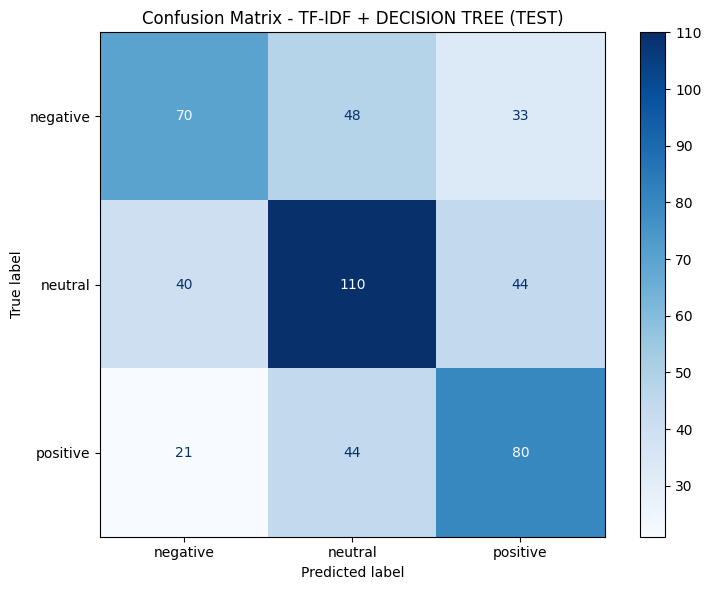

In [2]:
import pandas as pd
import re
import unicodedata
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

# =========================
# 1) Load dữ liệu (train/val/test)
# =========================
TRAIN_PATH = "./preprocessed-dataset/train_processed.json"
VAL_PATH   = "./preprocessed-dataset/dev_processed.json"
TEST_PATH  = "./preprocessed-dataset/test_processed.json"

SEED = 42

def load_json_flexible(path: str) -> pd.DataFrame:
    try:
        df = pd.read_json(path)
        print(f"Đọc JSON dạng array OK: {path}")
        return df
    except ValueError:
        df = pd.read_json(path, lines=True)
        print(f"Đọc JSON dạng lines OK: {path}")
        return df

df_train = load_json_flexible(TRAIN_PATH)
df_val   = load_json_flexible(VAL_PATH)
df_test  = load_json_flexible(TEST_PATH)

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    missing = {"review", "sentiment"} - set(d.columns)
    if missing:
        raise ValueError(f"Dataset {name} thiếu cột: {missing}. Các cột hiện có: {list(d.columns)}")

print("Train shape:", df_train.shape)
print("Val shape:", df_val.shape)
print("Test shape:", df_test.shape)

# =========================
# 2) Preprocessing: giữ như trước + bỏ dấu tiếng Việt
# =========================
def clean_review_basic(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_vietnamese_accents(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    text = unicodedata.normalize("NFC", text)
    return text

def preprocess_review(text):
    return remove_vietnamese_accents(clean_review_basic(text))

def normalize_sentiment_col(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()
    df["review_clean"] = df["review"].apply(preprocess_review)
    return df

df_train = normalize_sentiment_col(df_train)
df_val   = normalize_sentiment_col(df_val)
df_test  = normalize_sentiment_col(df_test)

# =========================
# 3) Encode label: fit trên train, transform cho val/test
# =========================
le = LabelEncoder()
le.fit(df_train["sentiment"])

train_labels_set = set(le.classes_)
val_extra = set(df_val["sentiment"].unique()) - train_labels_set
test_extra = set(df_test["sentiment"].unique()) - train_labels_set
if val_extra or test_extra:
    raise ValueError(
        "Val/Test có nhãn không xuất hiện trong Train.\n"
        f"Val extra labels: {sorted(val_extra)}\n"
        f"Test extra labels: {sorted(test_extra)}\n"
        f"Train labels: {list(le.classes_)}"
    )

df_train["label_id"] = le.transform(df_train["sentiment"])
df_val["label_id"]   = le.transform(df_val["sentiment"])
df_test["label_id"]  = le.transform(df_test["sentiment"])

print("Classes:", list(le.classes_))
print("Train label distribution:\n", df_train["sentiment"].value_counts())

X_train = df_train["review_clean"].values
y_train = df_train["label_id"].values

X_val = df_val["review_clean"].values
y_val = df_val["label_id"].values

X_test = df_test["review_clean"].values
y_test = df_test["label_id"].values

# =========================
# 4) Pipeline + GridSearchCV (CV trên TRAIN)
# =========================
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        token_pattern=r"(?u)\b\w+\b",
        lowercase=False
    )),
    ("dt", DecisionTreeClassifier(random_state=SEED)),
])

param_grid = {
    # TF-IDF
    "tfidf__ngram_range": [(1, 4)],
    "tfidf__max_df": [0.1],
    "tfidf__min_df": [2],
    "tfidf__sublinear_tf": [False], # DONE
    "tfidf__norm": ["l2"], # DONE

    # Decision Tree
    "dt__criterion": ["gini"],
    "dt__max_depth": [50],
    "dt__min_samples_split": [3],
    "dt__min_samples_leaf": [7],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

print("Đang GridSearchCV (F1-macro) trên TRAIN...")
grid.fit(X_train, y_train)

print("\nBest CV F1-macro:", grid.best_score_)
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"{k}: {v}")

# =========================
# 5) Đánh giá DEV (model đã refit trên TRAIN), rồi refit (train+val) và TEST
# =========================
def print_metrics(y_true, y_pred, split_name: str):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"\n{split_name} Accuracy: {acc}")
    print(f"{split_name} F1-macro: {f1m}")
    print(f"\nClassification report ({split_name}):")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format="d", colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# 5.1) Evaluate trên DEV (model tốt nhất đã refit trên TRAIN)
best_model = grid.best_estimator_  # đã được refit trên TRAIN vì refit=True
y_val_pred = best_model.predict(X_val)
print_metrics(y_val, y_val_pred, "DEV")
plot_confusion(y_val, y_val_pred, "Confusion Matrix - TF-IDF + DECISION TREE (DEV)")

# 5.2) Refit trên (train + dev) rồi TEST
X_trainval = pd.concat([df_train["review_clean"], df_val["review_clean"]], axis=0).values
y_trainval = pd.concat([df_train["label_id"], df_val["label_id"]], axis=0).values

final_model = best_model
final_model.fit(X_trainval, y_trainval)

y_test_pred = final_model.predict(X_test)
print_metrics(y_test, y_test_pred, "TEST")
plot_confusion(y_test, y_test_pred, "Confusion Matrix - TF-IDF + DECISION TREE (TEST)")